<a href="https://colab.research.google.com/github/PeesapatiRohithSharma/Summer_2026/blob/main/K_means_for_iris.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

In [ ]:
data = files.upload()

Saving Iris.csv to Iris.csv


In [ ]:
df = pd.read_csv('Iris.csv')

In [ ]:
df

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica


In [ ]:
df.drop('Id', axis=1)

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


In [ ]:
X = df.iloc[:,:5]

In [ ]:
X

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,1,5.1,3.5,1.4,0.2
1,2,4.9,3.0,1.4,0.2
2,3,4.7,3.2,1.3,0.2
3,4,4.6,3.1,1.5,0.2
4,5,5.0,3.6,1.4,0.2
...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3
146,147,6.3,2.5,5.0,1.9
147,148,6.5,3.0,5.2,2.0
148,149,6.2,3.4,5.4,2.3


In [ ]:
y = df.loc[:,'Species']

In [ ]:
y

,Species
0,Iris-setosa
1,Iris-setosa
2,Iris-setosa
3,Iris-setosa
4,Iris-setosa
...,...
145,Iris-virginica
146,Iris-virginica
147,Iris-virginica
148,Iris-virginica


In [ ]:
set(y)

{'Iris-setosa', 'Iris-versicolor', 'Iris-virginica'}

In [ ]:
y = y.map({'Iris-setosa':1, 'Iris-versicolor':2, 'Iris-virginica':3})

In [ ]:
colour = {1:'red', 2:'blue', 3:'green'}

In [ ]:
class K_means:
  def __init__(self, X, k):
    self.X = X
    self.k = k

  def initialize_centroids(self):
    random = np.random.choice(self.X.shape[0],self.k,replace=False)
    self.centroids = self.X[random]

  def new_classes(self):
    self.c=[]
    for i in range(self.X.shape[0]):
      dist = []
      for j in range(self.k):
        distances = np.linalg.norm(self.X[i]-self.centroids[j],2)
        dist.append(distances)
      self.c.append(np.argmin(dist))
    self.c = np.array(self.c)
    return self.c

  def update_centroids(self):
    new_centroids = []
    for j in range(self.k):
      sums = np.zeros(self.X.shape[1])
      counter = 0
      for i in range(self.X.shape[0]):
        if self.c[i] == j:
          sums += self.X[i]
          counter += 1
      if counter == 0:
        new_centroids.append(self.centroids[j])
      else:
        new_centroids.append(sums/counter)
    self.centroids = np.array(new_centroids)
    return self.centroids

  def fit(self, iterations=100):
    self.initialize_centroids()
    for _ in range(iterations):
      self.new_classes()
      self.update_centroids()
    return self.c




In [ ]:
y

,Species
0,1
1,1
2,1
3,1
4,1
...,...
145,3
146,3
147,3
148,3


In [ ]:
input = X.to_numpy()
model = K_means(input,3)
labels=model.fit()

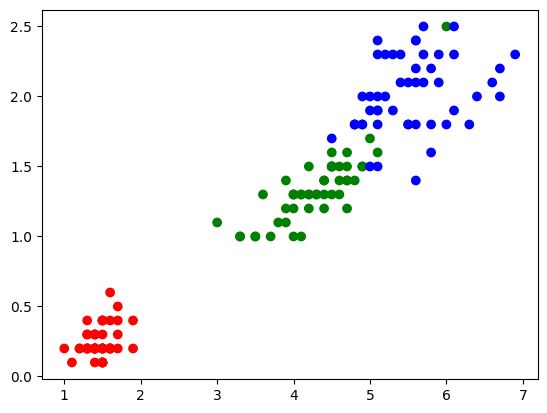

In [ ]:
plt.scatter(X['PetalLengthCm'],X['PetalWidthCm'],c=[colour[l] for l in labels+1])

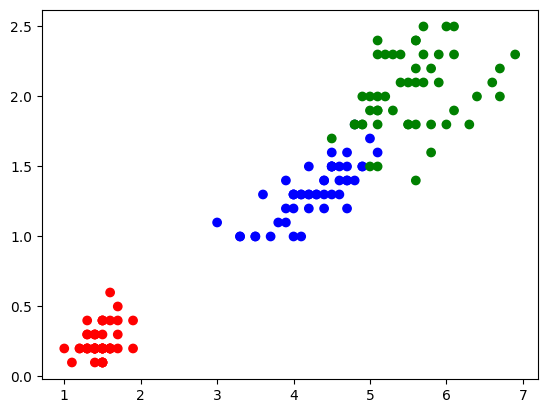

In [ ]:
plt.scatter(X['PetalLengthCm'],X['PetalWidthCm'],c=y.map(colour))

In [ ]:
labels+1

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [ ]:
y.to_numpy()

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3])

In [ ]:
from sklearn.metrics import silhouette_score
score = silhouette_score(X, model.c)
print("Silhouette Score:", score)

Silhouette Score: 0.5815388282262188
